# Topic Modeling with BERTopic

This notebook applies BERTopic to cleaned news articles to identify major themes in AI-related news coverage.

Main tasks:
- load cleaned text
- fit BERTopic
- inspect topic distributions
- assign topic labels
- save model and outputs

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd

path = "/content/drive/MyDrive/NLP Final Project/news_cleaned.parquet"  # change if needed
df = pd.read_parquet(path)

pd.set_option("display.max_colwidth", None)

Mounted at /content/drive


In [ ]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.5 MB/s eta 0:00:00


In [ ]:

SEED = 42

# -------------------------
# 1) Load + filter
# -------------------------
df = pd.read_parquet(path)
df["clean_text"] = df["clean_text"].astype(str)
df = df[df["clean_text"].str.len() >= 500].copy()

docs = df["clean_text"].tolist()
print("Docs used:", len(docs))

Docs used: 183369


In [ ]:
import numpy as np
import gc
import pandas as pd

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from umap import UMAP
import hdbscan
from bertopic.representation import MaximalMarginalRelevance

# -------------------------
# 2) Embedding model
# -------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------
# 3) Full-capacity vectorizer
# -------------------------
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "cookie","cookies","gdpr","newswire","newswires","feed","opens",
    "navigation","agreement","visitor","terms","privacy","preferences",
    "px","jpeg","jpg","png","rawpixel","istock","getty","shutterstock"
})

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),      # restore bigrams
    min_df=20,
    max_df=0.9,
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
)

# -------------------------
# 4) Higher-capacity UMAP
# -------------------------
umap_model = UMAP(
    n_neighbors=30,          # more global structure
    n_components=5,          # preserve more geometry
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)

# -------------------------
# 5) Clustering
# -------------------------
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=150,    # slightly more flexible
    min_samples=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=False    # keep False unless you need transform()
)

# -------------------------
# 6) Topic representation
# -------------------------
repr_model = MaximalMarginalRelevance(diversity=0.3)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    representation_model=repr_model,
    calculate_probabilities=False,
    verbose=True
)

# -------------------------
# 7) Embeddings
# -------------------------
embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float32)

topics, probs = topic_model.fit_transform(docs, embeddings)

df["topic"] = topics

print("Num topics (incl -1):", len(set(topics)))
print("Outlier rate:", (df["topic"] == -1).mean())

gc.collect()

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5731 [00:00<?, ?it/s]

2026-03-01 20:52:57,797 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-01 21:00:25,106 - BERTopic - Dimensionality - Completed ✓
2026-03-01 21:00:25,110 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-01 21:00:40,340 - BERTopic - Cluster - Completed ✓
2026-03-01 21:00:40,376 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-01 21:03:41,688 - BERTopic - Representation - Completed ✓


Num topics (incl -1): 163
Outlier rate: 0.4962452759190485


80664

In [ ]:
topic_model.reduce_topics(docs, nr_topics=100)

2026-03-01 21:05:44,622 - BERTopic - Topic reduction - Reducing number of topics
2026-03-01 21:05:44,813 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-01 21:08:49,084 - BERTopic - Representation - Completed ✓
2026-03-01 21:08:49,191 - BERTopic - Topic reduction - Reduced number of topics from 163 to 100


In [ ]:
import pandas as pd

topic_info = topic_model.get_topic_info()  # has Topic + Count + Name
# Keep all topics including -1 for now
rows = []
for tid in topic_info["Topic"].tolist():
    words = topic_model.get_topic(tid) or []
    kws = ", ".join([w for w, _ in words[:12]])
    rows.append({
        "topic_id": tid,
        "count": int(topic_info.loc[topic_info.Topic == tid, "Count"].values[0]),
        "keywords": kws
    })

topic_table = pd.DataFrame(rows).sort_values(["topic_id"])
topic_table

,topic_id,count,keywords
0,-1,90996,"prnewswire, communications, media group, gray media, gpt, newsletters, musk, altman, windows, copilot"
1,0,7884,"generated image, love hear, remix, discord, touch, backgrounds, flower, furniture, sky, wildlife"
2,1,4084,"biden, white house, congress, elections, executive order, senate, regulations, donald, schumer, democratic"
3,2,4052,"clinical, doctors, drug discovery, imaging, diagnosis, protein, outcomes, breast cancer, patient care, fda"
4,3,4049,"trading, mexc, exchange rates, converter, conversions, futures, currency, casinos, market sentiment, cryptocurrencies"
...,...,...,...
95,94,161,"summit, interviews, home features, market pulse, exclusive interviews, sign welcome, news events, conferences, forum, twitch"
96,95,160,"valley, freddy, corridor, cameras, free apps, news tip, metv, tech life, items home, talk business"
97,96,158,"sexual abuse, child sexual, law enforcement, pornography, imagery, abuse material, child abuse, child safety, thorn, abusive"
98,97,155,"api, devops, cookielawinfo, consent plugin, checkbox, microservices, secrets, store user, developer, cloud native"


In [ ]:
import pandas as pd

topic_info = topic_model.get_topic_info()

rows = []

for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue

    words = topic_model.get_topic(topic_id)

    rows.append({
        "topic_id": topic_id,
        "count": int(topic_info.loc[topic_info.Topic == topic_id, "Count"]),
        "keywords": [w for w, _ in words[:10]],
        "weights": [round(float(wt), 4) for _, wt in words[:10]]
    })

topic_table = pd.DataFrame(rows)
topic_table.head()

,topic_id,count,keywords,weights
0,0,7884,"[generated image, love hear, remix, discord, touch, backgrounds, flower, furniture, sky, wildlife]","[0.1784, 0.1064, 0.1057, 0.1009, 0.0904, 0.0207, 0.0193, 0.0186, 0.0116, 0.0103]"
1,1,4084,"[biden, white house, congress, elections, executive order, senate, regulations, donald, schumer, democratic]","[0.0088, 0.0068, 0.0057, 0.0053, 0.0047, 0.0044, 0.0041, 0.004, 0.0037, 0.0033]"
2,2,4052,"[clinical, doctors, drug discovery, imaging, diagnosis, protein, outcomes, breast cancer, patient care, fda]","[0.0206, 0.0092, 0.0091, 0.008, 0.0079, 0.0079, 0.0075, 0.0067, 0.0063, 0.0054]"
3,3,4049,"[trading, mexc, exchange rates, converter, conversions, futures, currency, casinos, market sentiment, cryptocurrencies]","[0.0363, 0.0238, 0.0225, 0.0194, 0.0161, 0.0147, 0.014, 0.0137, 0.0132, 0.0122]"
4,4,3843,"[entrepreneur, enterprises, venturebeat, startups, workflows, market research, forecast period, supply chain, fintech, firms]","[0.0072, 0.0047, 0.0044, 0.0034, 0.0033, 0.0033, 0.0031, 0.003, 0.003, 0.0028]"


In [ ]:
topic_info = topic_model.get_topic_info()
topic_info = topic_info.drop(columns=["Representative_Docs"], errors="ignore")
topic_info["proportion"] = topic_info["Count"] / topic_info["Count"].sum()
topic_info.sort_values("proportion", ascending=False).head(10)

,Topic,Count,Name,Representation,proportion
0,-1,90996,-1_prnewswire_communications_media group_gray media,"[prnewswire, communications, media group, gray media, gpt, newsletters, musk, altman, windows, copilot]",0.496245
1,0,7884,0_generated image_love hear_remix_discord,"[generated image, love hear, remix, discord, touch, backgrounds, flower, furniture, sky, wildlife]",0.042995
2,1,4084,1_biden_white house_congress_elections,"[biden, white house, congress, elections, executive order, senate, regulations, donald, schumer, democratic]",0.022272
3,2,4052,2_clinical_doctors_drug discovery_imaging,"[clinical, doctors, drug discovery, imaging, diagnosis, protein, outcomes, breast cancer, patient care, fda]",0.022098
4,3,4049,3_trading_mexc_exchange rates_converter,"[trading, mexc, exchange rates, converter, conversions, futures, currency, casinos, market sentiment, cryptocurrencies]",0.022081
5,4,3843,4_entrepreneur_enterprises_venturebeat_startups,"[entrepreneur, enterprises, venturebeat, startups, workflows, market research, forecast period, supply chain, fintech, firms]",0.020958
6,5,3728,5_nasdaq_symbols_quotes_stocks,"[nasdaq, symbols, quotes, stocks, watchlist, earnings, amzn, investor relations, index, etf]",0.020331
7,6,3550,6_media group_cox media_gray media_file new,"[media group, cox media, gray media, file new, understand options, careers cox, learn careers, accept policy, station, prnewswire]",0.019360
8,7,3337,7_delhi_minister_iit_bengaluru,"[delhi, minister, iit, bengaluru, summit, singh, bjp, kerala, telangana, narendra modi]",0.018198
9,8,2462,8_presswire_ein presswire_press releases_newsplugin,"[presswire, ein presswire, press releases, newsplugin, maker newsplugin, newsroom investor, distribution editorial, newsplugin help, program rss, presswire newsroom]",0.013426


In [ ]:
topic_model.visualize_barchart(top_n_topics=20)

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_info = topic_model.get_topic_info()

# remove outlier topic -1 if you want
topic_info = topic_info[topic_info["Topic"] != -1]

topic_info["proportion"] = topic_info["Count"] / topic_info["Count"].sum()

import pandas as pd

bins = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 1]
labels = [
    "0–0.1%",
    "0.1–0.5%",
    "0.5–1%",
    "1–2%",
    "2–5%",
    ">5%"
]

topic_info["size_bin"] = pd.cut(topic_info["proportion"], bins=bins, labels=labels)

bin_counts = topic_info["size_bin"].value_counts().sort_index()

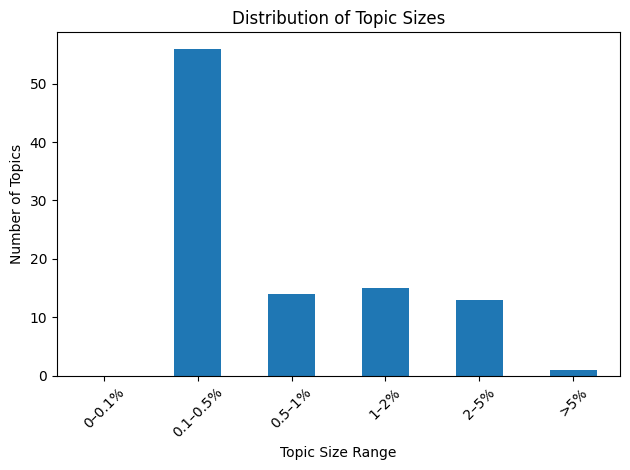

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
bin_counts.plot(kind="bar")

plt.xlabel("Topic Size Range")
plt.ylabel("Number of Topics")
plt.title("Distribution of Topic Sizes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()